# Color Segmentation

Red/blue/yellow color segmentation and combined-mask contour extraction for locating a traffic sign's region of interest.

The segmentation functions themselves (`segment_red`, `segment_blue`, `segment_yellow`, `find_best_contour`, `extract_roi_from_mask`, ...) live in `pipeline/segmentation.py` - this notebook imports and demonstrates them on real images from the cleaned dataset (`00-dataset/02_clean_annotations.ipynb`'s output) instead of defining them inline. `02-feature-extraction` and `03-classifier/03_svm_classifier.ipynb` import the same module, so there is exactly one implementation of this logic in the repo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from pipeline import annotations, segmentation

## Load a handful of real sample images

In [2]:
annotations_df, image_lookup = annotations.load_annotations()

sample_indices = np.linspace(
    0, len(annotations_df) - 1, num=6, dtype=int
).tolist()

sample_rows = annotations_df.iloc[sample_indices]
print(sample_rows[["file_name", "category"]])

               file_name  category
0           000_0001.png         0
1199        004_0043.png         4
2398      007_1_0049.png         7
3598      024_1_0041.png        24
4797      039_0007_j.png        39
5997  057_1_0002_1_j.png        57


## Red, blue and yellow masks on each sample

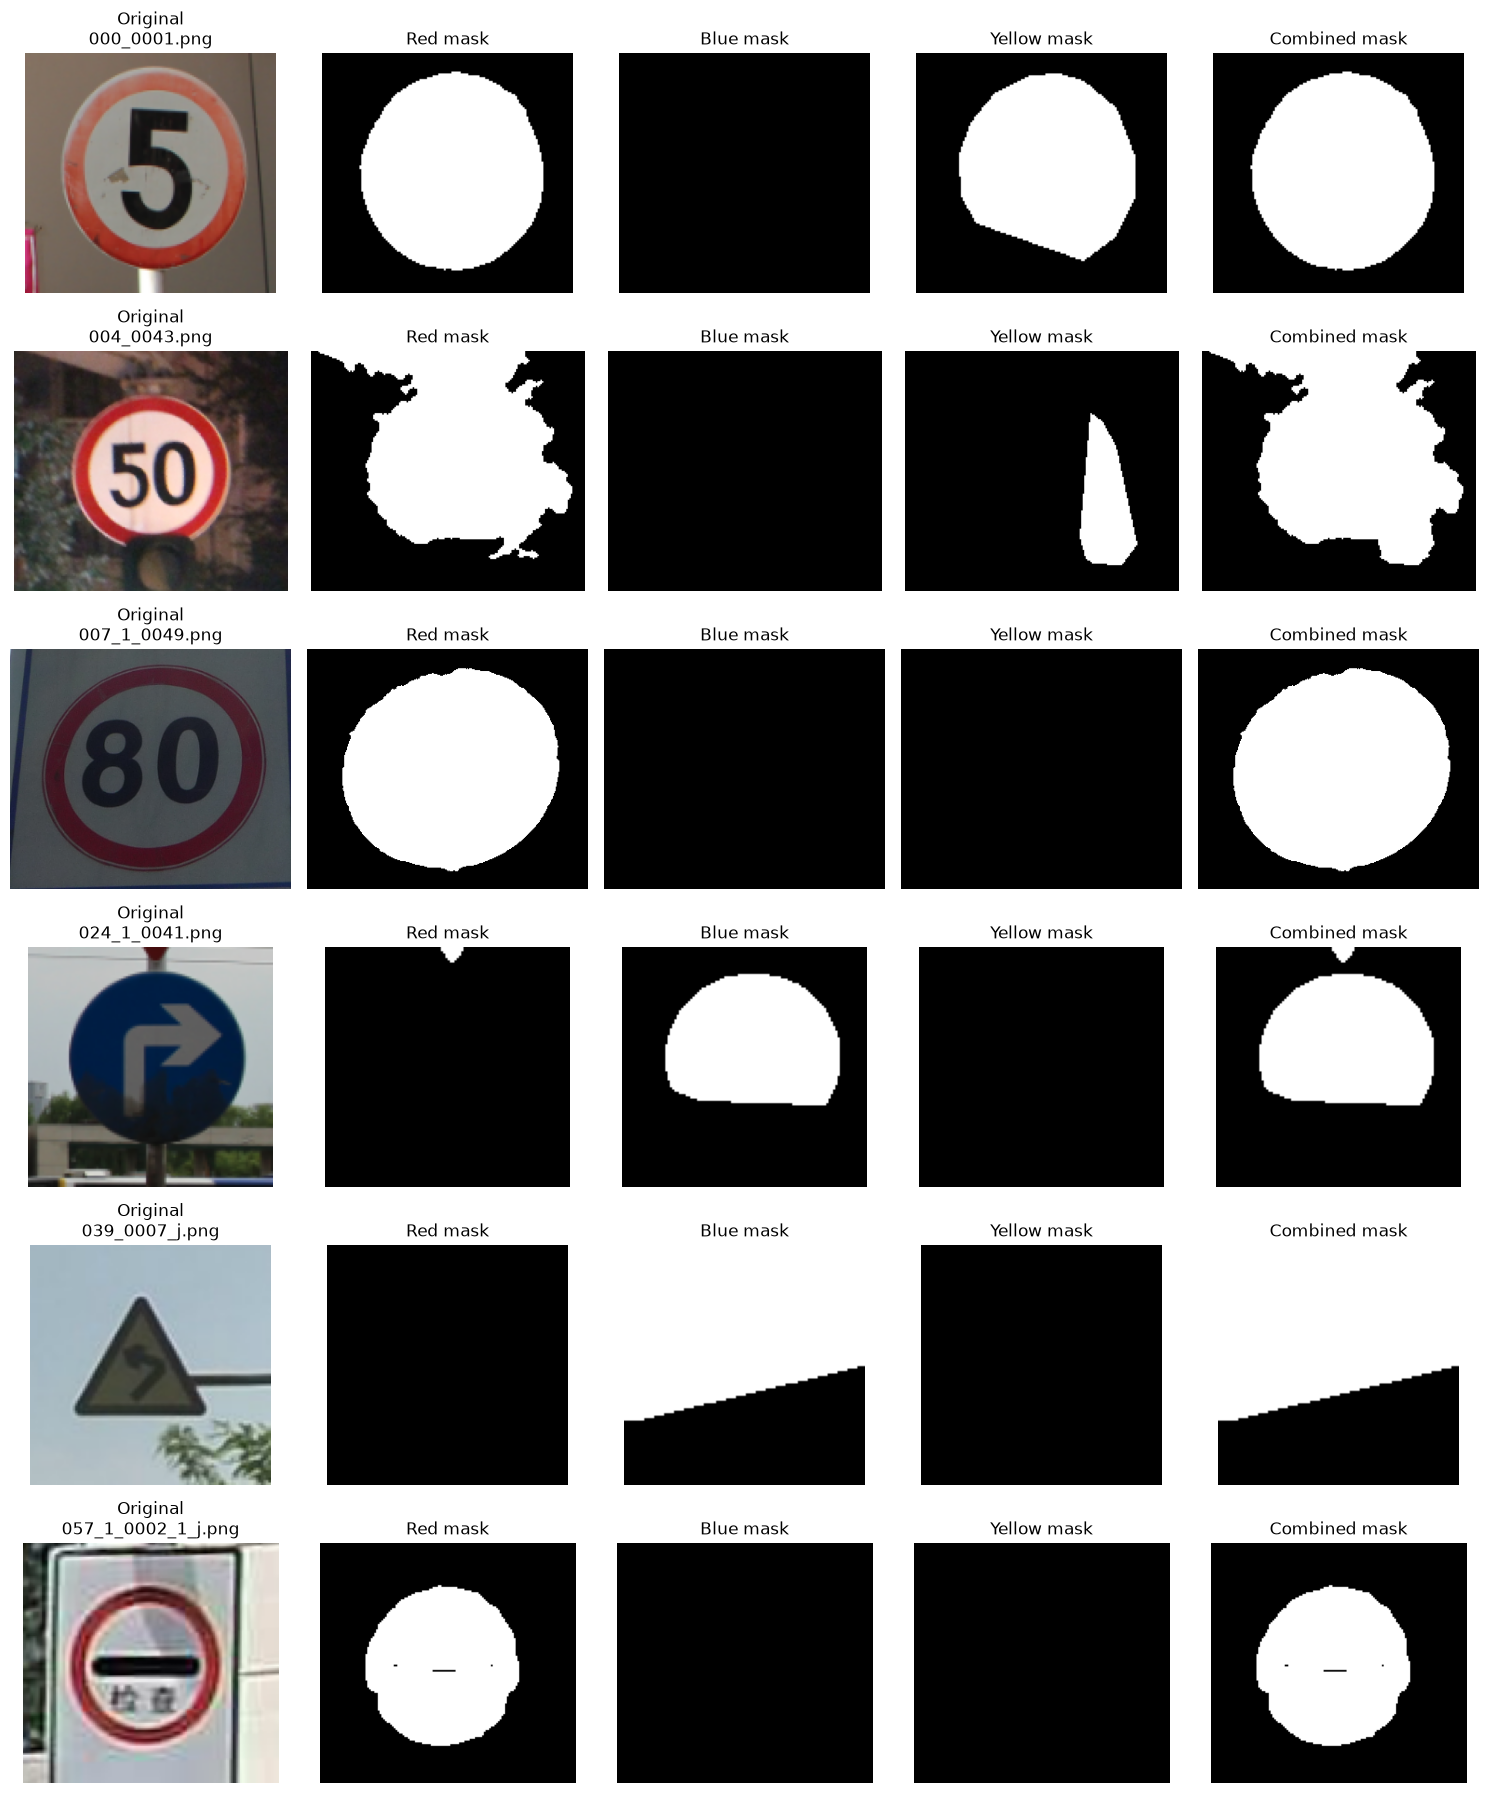

Traffic sign contour detected: 6/6


In [3]:
fig, axes = plt.subplots(len(sample_rows), 5, figsize=(15, 3 * len(sample_rows)))

detected = 0

for row_index, (_, row) in enumerate(sample_rows.iterrows()):
    image_path = image_lookup[row["file_name"]]
    img_rgb = segmentation.load_image(str(image_path))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    red_mask = segmentation.segment_red(img_bgr)
    blue_mask = segmentation.segment_blue(img_bgr)
    yellow_mask = segmentation.segment_yellow(img_bgr)
    combined_mask = red_mask | blue_mask | yellow_mask

    if segmentation.find_best_contour(combined_mask) is not None:
        detected += 1

    for col, (title, image, cmap) in enumerate([
        ("Original", img_rgb, None),
        ("Red mask", red_mask, "gray"),
        ("Blue mask", blue_mask, "gray"),
        ("Yellow mask", yellow_mask, "gray"),
        ("Combined mask", combined_mask, "gray"),
    ]):
        axes[row_index, col].imshow(image, cmap=cmap)
        axes[row_index, col].set_title(f"{title}\n{row['file_name']}" if col == 0 else title)
        axes[row_index, col].axis("off")

plt.tight_layout()
plt.show()

print(f"Traffic sign contour detected: {detected}/{len(sample_rows)}")

## Extract the ROI from the combined mask

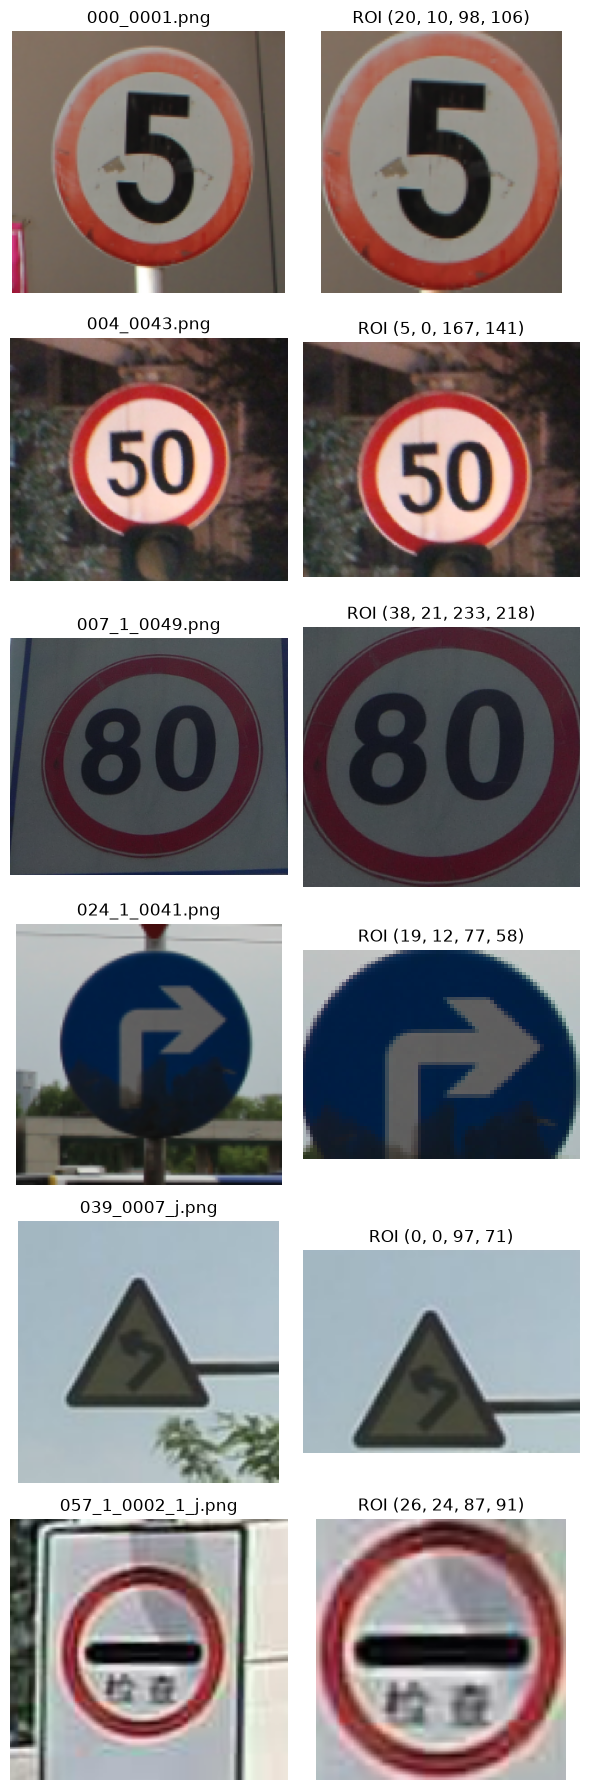

In [4]:
fig, axes = plt.subplots(len(sample_rows), 2, figsize=(6, 3 * len(sample_rows)))

for row_index, (_, row) in enumerate(sample_rows.iterrows()):
    image_path = image_lookup[row["file_name"]]
    img_rgb = segmentation.load_image(str(image_path))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    combined_mask = (
        segmentation.segment_red(img_bgr)
        | segmentation.segment_blue(img_bgr)
        | segmentation.segment_yellow(img_bgr)
    )

    roi, bbox, best_contour = segmentation.extract_roi_from_mask(img_rgb, combined_mask)

    axes[row_index, 0].imshow(img_rgb)
    axes[row_index, 0].set_title(row["file_name"])
    axes[row_index, 0].axis("off")

    if roi is not None:
        axes[row_index, 1].imshow(roi)
        axes[row_index, 1].set_title(f"ROI {bbox}")
    else:
        axes[row_index, 1].text(0.5, 0.5, "No ROI detected", ha="center", va="center")
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()